# Intelligent Patient Risk Assessment  
## Cholesterol Risk — Full Advanced Pipeline (Training + Evaluation + Comparison)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

import joblib
import os

print("Libraries loaded")

Libraries loaded


In [2]:
from google.colab import files
import io

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

df.head()

Saving feature_engineered_data.csv to feature_engineered_data.csv


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,obesity_risk_score,cholesterol_risk_score,high_bp_flag,bmi_age_interaction,combined_risk_index,age_group_middle,age_group_senior,bmi_category_obese,bmi_category_overweight,bmi_category_underweight
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,57.387241,51.492983,1,1769.0,52.994839,False,True,True,False,False
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,36.219202,3.984993,1,1201.2,27.620116,False,True,False,False,False
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,42.898797,21.793300,0,1332.0,40.128196,False,True,False,False,False
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,52.194082,22.962029,0,1983.2,49.950427,False,True,False,True,False
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,32.095465,34.296907,0,975.2,26.634294,True,False,False,False,False


In [4]:
print(df.shape)
df.info()

(97297, 41)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 41 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  object 
 2   ethnicity                           97297 non-null  object 
 3   education_level                     97297 non-null  object 
 4   income_level                        97297 non-null  object 
 5   employment_status                   97297 non-null  object 
 6   smoking_status                      97297 non-null  object 
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day    

In [5]:
df.describe()

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,insulin_level,hba1c,diabetes_risk_score,hypertension_risk_score,heart_disease_risk_score,obesity_risk_score,cholesterol_risk_score,high_bp_flag,bmi_age_interaction,combined_risk_index
count,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,...,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000
mean,50.192699,2.004543,118.942886,5.995214,6.997708,5.997031,0.219657,0.250912,0.079067,25.615093,...,9.063591,6.520338,41.237414,41.137170,32.063255,48.407241,26.075076,0.249484,1290.901211,37.784031
std,15.492557,1.418060,84.441920,1.780096,1.093726,2.469805,0.414017,0.433540,0.269845,3.588387,...,4.956342,0.813710,10.990720,12.755572,15.412755,10.998884,13.028452,0.432716,454.906256,9.445507
min,19.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,2.000000,4.000000,1.821211,0.000000,0.000000,12.711686,0.000000,0.000000,288.800000,6.646049
25%,38.000000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,5.090000,5.970000,33.611350,32.136805,20.389335,40.898793,16.506114,0.000000,951.200000,31.097237
50%,51.000000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,8.790000,6.520000,40.773364,40.941950,30.793098,48.509658,25.497612,0.000000,1265.000000,37.560495
75%,61.000000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,12.450000,7.070000,48.430041,49.911238,42.564698,55.928994,34.804830,0.000000,1586.000000,44.215903
max,90.000000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,32.220000,9.800000,84.329497,92.102337,97.902483,86.832124,83.112231,1.000000,3294.000000,80.517803


CLASSIFICATION PIPELINE

In [6]:
target_col = "cholesterol_risk_score"

df["target_class"] = pd.qcut(
    df[target_col],
    q=3,
    labels=[0,1,2],
    duplicates="drop"
)

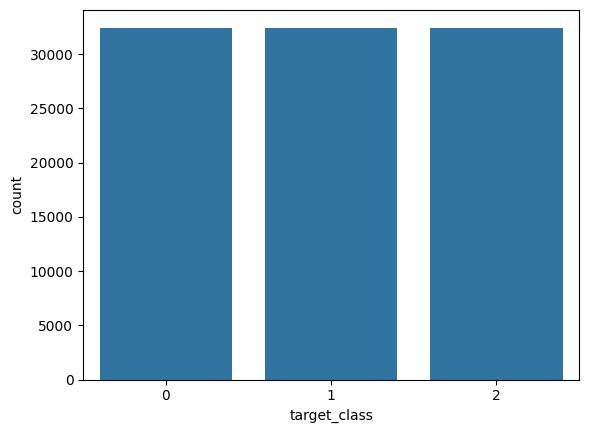

In [7]:
sns.countplot(x="target_class", data=df)
plt.show()

In [8]:
risk_cols = [
    "diabetes_risk_score",
    "heart_disease_risk_score",
    "hypertension_risk_score",
    "obesity_risk_score",
    "cholesterol_risk_score",
    "combined_risk_index"
]

existing = [c for c in risk_cols if c in df.columns]

X = df.drop(columns=existing + ["target_class"], errors="ignore")
y = df["target_class"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
X_all = pd.concat([X_train, X_test])

cat_cols = X_all.select_dtypes(include="object").columns

if len(cat_cols) > 0:
    X_all = pd.get_dummies(X_all, columns=cat_cols, drop_first=True)

X_train = X_all.iloc[:len(X_train)]
X_test = X_all.iloc[len(X_train):]

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MODELS

Logistic Regression

In [12]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

Decision Tree

In [13]:
dt_model = DecisionTreeClassifier(max_depth=6)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6)

In [14]:
def eval_cls(name, model, scaled=False):
    if scaled:
        preds = model.predict(X_test_scaled)
    else:
        preds = model.predict(X_test)

    return {
        "accuracy": accuracy_score(y_test, preds),
        "f1": f1_score(y_test, preds, average="weighted")
    }

In [15]:
log_res = eval_cls("log", log_model, scaled=True)
dt_res = eval_cls("dt", dt_model)

In [16]:
comparison = pd.DataFrame([
    ["Logistic", log_res["accuracy"], log_res["f1"]],
    ["Decision Tree", dt_res["accuracy"], dt_res["f1"]]
], columns=["Model","Accuracy","F1"])

comparison

,Model,Accuracy,F1
0,Logistic,0.938746,0.938720
1,Decision Tree,0.905036,0.905334


In [17]:
best_cls_model = log_model

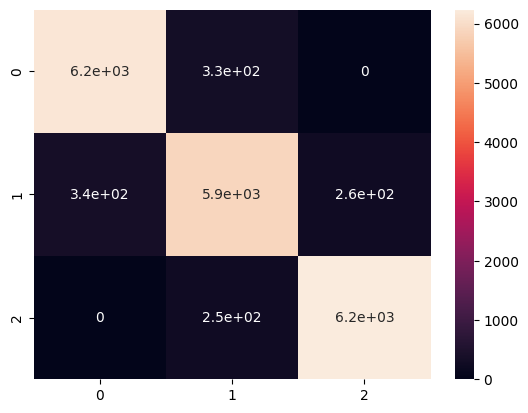

In [18]:
y_pred = best_cls_model.predict(X_test_scaled)

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.show()

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      6487
           1       0.91      0.91      0.91      6486
           2       0.96      0.96      0.96      6487

    accuracy                           0.94     19460
   macro avg       0.94      0.94      0.94     19460
weighted avg       0.94      0.94      0.94     19460



In [20]:
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))

Precision: 0.9386972896658234
Recall: 0.9387461459403905


In [21]:
y_prob = best_cls_model.predict_proba(X_test_scaled)
roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
print("ROC AUC:", roc_auc)

ROC AUC: 0.9924803440281499


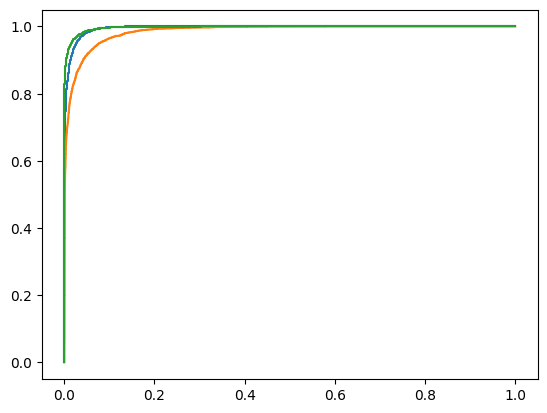

In [22]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr)

plt.show()

REGRESSION PART

In [23]:
y_reg = df[target_col]
X_reg = df.drop(columns=existing, errors="ignore")

In [24]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [25]:
Xr_all = pd.concat([Xr_train, Xr_test])

cat_cols = Xr_all.select_dtypes(include="object").columns

if len(cat_cols) > 0:
    Xr_all = pd.get_dummies(Xr_all, columns=cat_cols, drop_first=True)

Xr_train = Xr_all.iloc[:len(Xr_train)]
Xr_test = Xr_all.iloc[len(Xr_train):]

In [26]:
scaler_reg = StandardScaler()

Xr_train_scaled = scaler_reg.fit_transform(Xr_train)
Xr_test_scaled = scaler_reg.transform(Xr_test)

Linear Regression

In [27]:
lin_reg = LinearRegression()
lin_reg.fit(Xr_train_scaled, yr_train)

LinearRegression()

Decision Tree Regressor (Comparison)

In [28]:
dt_reg = DecisionTreeRegressor(max_depth=6)
dt_reg.fit(Xr_train, yr_train)

DecisionTreeRegressor(max_depth=6)

In [29]:
yr_pred_lin = lin_reg.predict(Xr_test_scaled)
yr_pred_dt = dt_reg.predict(Xr_test)

In [30]:
def eval_reg(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

In [31]:
lin_res = eval_reg(yr_test, yr_pred_lin)
dt_res = eval_reg(yr_test, yr_pred_dt)

In [32]:
reg_df = pd.DataFrame([
    ["Linear", lin_res["MAE"], lin_res["RMSE"], lin_res["R2"]],
    ["Decision Tree", dt_res["MAE"], dt_res["RMSE"], dt_res["R2"]]
], columns=["Model","MAE","RMSE","R2"])

reg_df

,Model,MAE,RMSE,R2
0,Linear,1.314133,1.711882,0.982918
1,Decision Tree,1.888143,2.378804,0.967015


In [33]:
best_reg_model = lin_reg

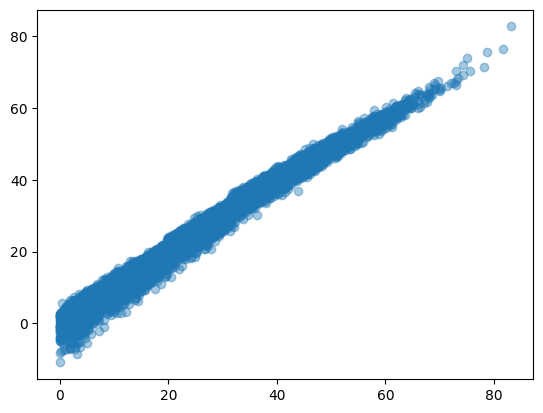

In [34]:
plt.scatter(yr_test, yr_pred_lin, alpha=0.4)
plt.show()

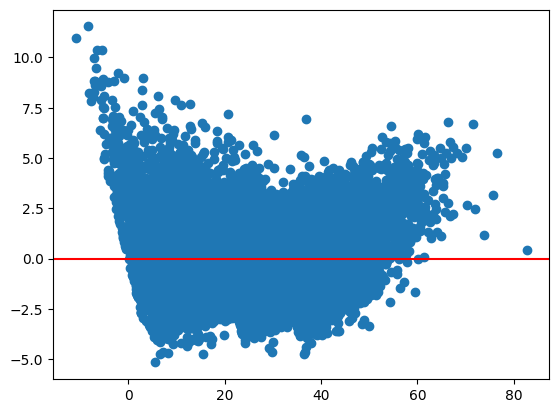

In [35]:
res = yr_test - yr_pred_lin

plt.scatter(yr_pred_lin, res)
plt.axhline(0,color="red")
plt.show()

In [36]:
scores = cross_val_score(lin_reg, Xr_train_scaled, yr_train, cv=5, scoring="r2")
print("CV R2:", scores.mean())

CV R2: 0.982720763057608


In [37]:
pd.Series(lin_reg.coef_, index=Xr_train.columns).sort_values(ascending=False).head(10)

,0
ldl_cholesterol,5.439106
cholesterol_total,4.534489
triglycerides,1.283758
target_class,1.056332
bmi_age_interaction,0.249397
bmi_category_obese,0.030741
glucose_fasting,0.025925
bmi_category_underweight,0.020842
diastolic_bp,0.012773
ethnicity_White,0.012237


In [38]:
os.makedirs("models", exist_ok=True)

joblib.dump(lin_reg, "models/cholesterol_reg_model.pkl")
joblib.dump(scaler_reg, "models/cholesterol_scaler.pkl")
joblib.dump(list(Xr_train.columns), "models/cholesterol_features.pkl")

['models/cholesterol_features.pkl']

In [39]:
print("Cholesterol Full Pipeline Completed Successfully!")

Cholesterol Full Pipeline Completed Successfully!


### Model Training Completed

Models:
- Logistic Regression  
- Decision Tree  
- Linear Regression  

Best:
- Logistic Regression (classification)
- Linear Regression (regression)